# ETF Arbitrage

## Data

Use the data in `data/etf_arb_data.xlsx`
* tab `descriptions`: fund snapshot as of the quote date
* tab `prices`: daily closing price per share
* tab `nav`: daily net asset value (NAV) per share

The premium/discount of price to NAV is

$$\frac{P_t}{\text{NAV}_t} - 1$$

A positive value is a premium; a negative value is a discount.

The file includes SPY (S&P 500 equities), HYG (high-yield corporate bonds), and GBTC (bitcoin). This exercise uses SPY and HYG.

#### Note

The prices are split-adjusted but not dividend-adjusted, so each day's price and NAV are comparable per-share quotes. (See the discussion of ETFs for more on measuring the premium.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 14

In [2]:
FILEDATA = 'etf_arb_data.xlsx'

info   = pd.read_excel(FILEDATA, sheet_name='descriptions', index_col=0)
prices = pd.read_excel(FILEDATA, sheet_name='prices', index_col=0)
nav    = pd.read_excel(FILEDATA, sheet_name='nav', index_col=0)

fund_info = info.rename(columns={
    'name': 'Name',
    'quoteType': 'Type',
    'currency': 'Currency',
    'volume': 'Volume',
    'totalAssets': 'Total Assets',
    'expense_ratio': 'Expense Ratio',
    'as_of': 'As of',
}).rename_axis('Ticker')

(fund_info.style
 .format({
     'Volume': '{:,.0f}',
     'Total Assets': lambda x: f'${x / 1e9:,.1f}B',
     'Expense Ratio': '{:.2%}',
 })
 .set_properties(
     subset=['Volume', 'Total Assets', 'Expense Ratio'],
     **{'text-align': 'right', 'padding-left': '1.25em'},
 ))

,Name,Type,Currency,Volume,Total Assets,Expense Ratio,As of
Ticker,,,,,,,
SPY,SS SPDR S&P 500 ETF TRUST-US,ETP,USD,"87,683,517",$776.9B,0.09%,2026-06-09
HYG,ISHR IBX USD HIYLD CB ETF-UI,ETP,USD,"34,705,836",$16.1B,0.49%,2026-06-09
GBTC,GRAYSCALE BITCOIN TRUST ETF,ETP,USD,"3,067,475",$8.9B,1.50%,2026-06-09


***

# 1. The SPY Premium

SPY creations and redemptions are done in units of 50,000 shares. (See the discussion of ETFs for the mechanics of creation and redemption.)

### 1.1.

For each fund, calculate the daily premium/discount.

For SPY, report the mean, standard deviation, min, and max, in basis points. Plot the series over time.

How closely does SPY trade to its NAV on a typical day?

{'mean': 0.30484242292615127, 'std': 4.225173387835398, 'min': -79.8013897560279, 'max': 90.04197348582154}


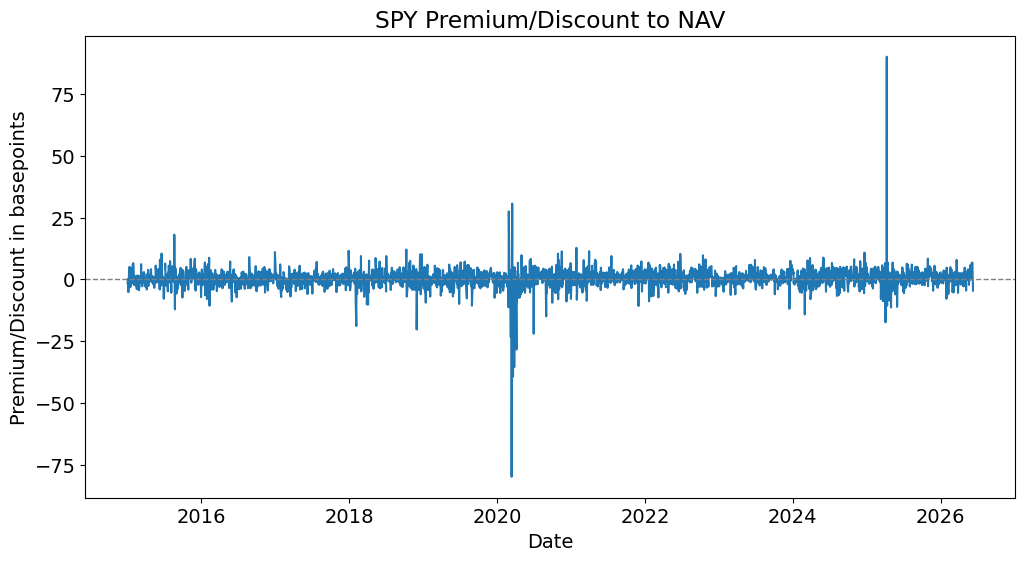

In [11]:
#1.1 
spy_premium = premium['SPY']
spy_stats= {
    'mean': spy_premium.mean() * 10000,
    'std' : spy_premium.std() * 10000,
    'min': spy_premium.min() * 10000,
    'max': spy_premium.max() * 10000,
}    
print(spy_stats)


plt.plot(spy_premium.index, spy_premium * 10000)
plt.xlabel('Date')
plt.ylabel('Premium/Discount in basepoints')
plt.title('SPY Premium/Discount to NAV')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.show()


# On a typical day SPY tracks its NAV extremely well with a standard deviation of about 4.2 base points.

### 1.2.

Suppose SPY closes at a 0.50% premium to NAV.

Describe in detail the trade an authorized participant would put on to capture this. Specify each leg: what is bought, what is delivered, and what is sold.

Using the most recent NAV in the data, calculate the gross profit on one creation unit (50,000 shares).

In [13]:
#1.2
# When SPY trades above NAV an authorized participant would want to buy the basket of 
# S&P 500 stocks in the open market.  Then they would deliver that basket to SPY's sponsor in exchange 
# SPY shares.  Then they would sell those SPY shares in the open market where it is trading at 0.5% premium.  
# The profit would be the premium (0.5%) multiplied by the SPY NAV multiplied by the number of shares.

recent_nav_spy = nav['SPY'].iloc[-1]
premium_pct = 0.005
shares = 50000
profit = premium_pct * recent_nav_spy * shares
print( "Gross profit on one creation unit: $", profit)

# However, this doesn't take into account transaction costs and the bid ask spread which have potential 
# to drastically change whether or not this is profitable

Gross profit on one creation unit: $ 184346.4


### 1.3.

Suppose the authorized participant pays a \$3,000 creation fee per order, plus 3 basis points in trading costs on the basket.

At what premium does the creation trade break even?

Compare this breakeven to your statistics from 1.1. What keeps SPY trading in such a tight band?

In [17]:
#1.3
basket_value = recent_nav_spy * shares
trading_cost_pct = 0.0003

breakeven_premium = trading_cost_pct + 3000 / basket_value
print("Break-even premium is ", breakeven_premium)

# The break-even is one standard deviation below SPY's typical daily premium fluctuation.
# This means that you would have chances to break-even / make money very frequently.
# This keeps SPY trading in such a tight band because market makers / authorized participants would 
# want to step in as soon as the premium drifts above the break-even.  The act of them doing this 
# would push the premium back down.  


Break-even premium is  0.00038136855398315344


***

# 2. HYG in March 2020

HYG holds high-yield corporate bonds, a much less liquid basket than the S&P 500.

### 2.1.

Plot HYG's premium/discount for 2020. Report the deepest discount and the largest premium of the year, along with their dates.

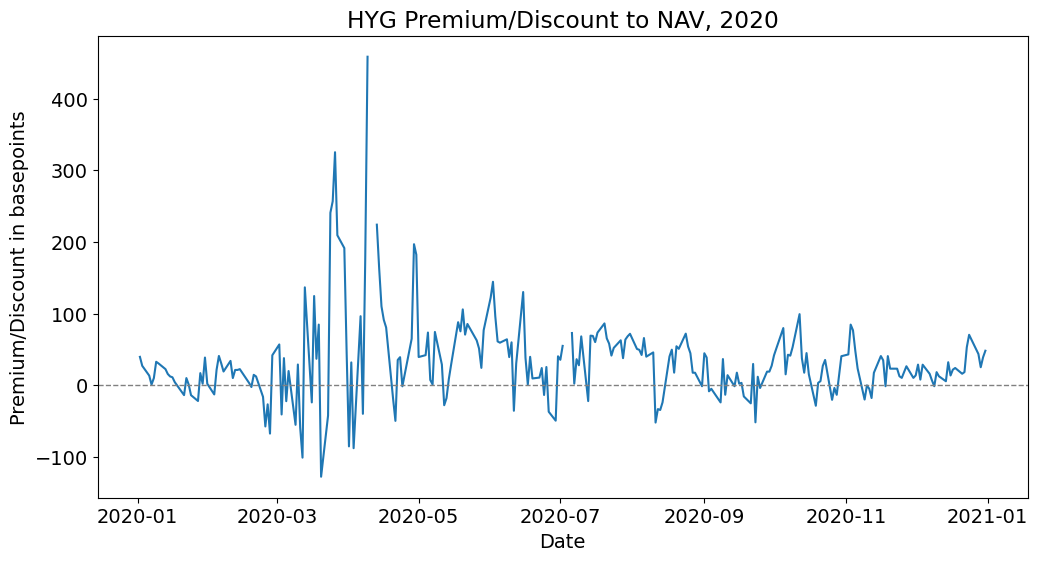

In [19]:
#2.1
hyg_premium = premium['HYG']
hyg_2020 = hyg_premium[hyg_premium.index.year == 2020]
plt.plot(hyg_2020.index, hyg_2020 * 10000)
plt.xlabel('Date')
plt.ylabel('Premium/Discount in basepoints')
plt.title('HYG Premium/Discount to NAV, 2020')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.show()

In [21]:
deepest_discount_date= hyg_2020.idxmin()
deepest_discount_value = hyg_2020.min()

largest_premium_date = hyg_2020.idxmax()
largest_premium_value = hyg_2020.max()

print("Deepest discount: ", deepest_discount_value*10000, "on ", deepest_discount_date)
print("Largest premium: ", largest_premium_value*10000, "on ", largest_premium_date)

Deepest discount:  -127.38853503184822 on  2020-03-20 00:00:00
Largest premium:  458.4126984126979 on  2020-04-09 00:00:00


### 2.2.

Consider the discount of March 2020. The redemption trade would be to buy HYG at the discount, redeem the shares for the bonds, and sell the bonds at their NAV marks.

Is this an arbitrage? Give at least two reasons the discount was not free money.

In [ ]:
# Technically this is an arbitrage.  However, this was about when COVID started to become a global pandemic
# causing a liquidity crunch which meant that many of the bonds in the ETF weren't trading, so the move wouldn't 
# have actually been achieveable.  
# Another reason would also be the execution and settlement risk.  Even if you were able to buy during this crisis
# there is no promise that you would be able to settle and sell, during which time you have assets which could crash further. 


### 2.3.

In those weeks, which was the better measure of the portfolio's value: the ETF price or the NAV?

What does the premium of April 2020 indicate on this question?

In [ ]:
# The ETF was probbaly the better measure of true value since it was liquid and actively being traded during that time.
# The "mispriced" ETF asset was actually more informative about the correct price than the outdated NAV benchmark.
# The premium indicates that price discovery was happening during this time because of environmental / governmental changes
# since it went from a discount to a premium over the course of a month.  